<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/KUIS1/KUIS1_244107020086_Zacky_Rio_Orlando.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [8]:
# Pengecekan Tipe Data
df.info()

# Mengetahui jumlah data yang hilang untuk setiap kolom
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


Variabel yang memiliki nilai hilang itu terdapat pada variabel workclass, occupation, native-country dan untuk jumlahnya workclass terdapat 963 data yang hilang, occupation ada 966 data yang hilang dan native-countru ada 274 data yang hilang.

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [12]:
# Proses data imputation

# workclass - modus
df['workclass'].fillna(value=df['workclass'].mode()[0], inplace=True)

# occupation - modus
df['occupation'].fillna(value=df['occupation'].mode()[0], inplace=True)

# native-country - modus
df['native-country'].fillna(value=df['native-country'].mode()[0], inplace=True)

# Mengecek lagi apakah ada data yang hilang atau tidak
df.isnull().sum()

/tmp/ipykernel_1652/3455378048.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['workclass'].fillna(value=df['workclass'].mode()[0], inplace=True)
/tmp/ipykernel_1652/3455378048.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


disini saya melakukan data imputasi menggunakan modus karena data pada variabel workclass, occupation, dan native-country berupa string dan setelah dilakukan data imputasi terlihat bahwa sudah tidak ada data yang hilang

## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [19]:
# Fungsi ini untuk melihat semua value unik pada fitur kualitatif
fitur_kualitatif = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]

for kolom in fitur_kualitatif:
    print(f"\n{kolom}:")
    print(sorted(df[kolom].dropna().unique()))


workclass:
['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

education:
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital-status:
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation:
['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

relationship:
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race:
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

sex:
['Female', 'Male']

native-country:
['?', 'Cambodia', 'Canada', 'China', 'Columbia

Setelah melihat value unique pada setiap variabel disini terlihat bahwa ada value "?" nah ini nanti akan diganti menjadi "other" dan juga ada beberapa typo yang saya ketahui pada variabel native-country seperti  Hong menjadi Hong Kong, Columbia menjadi Colombia, Holand-Netherlands menjadi Netherlands dan Trinadad&Tobago menjadi Trinidad&Tobago.

In [23]:
# Melalukan penggantian dan memperbaiki typo yang ada di valuenya
df['workclass'] = df['workclass'].replace('?', 'Others')

df['occupation'] = df['occupation'].replace('?', 'Others')

df['native-country'] = df['native-country'].replace({
    '?': 'Others',
    'Columbia': 'Colombia',
    'Hong': 'Hong Kong',
    'Holand-Netherlands': 'Netherlands',
    'Trinadad&Tobago': 'Trinidad&Tobago'
})

# Melakukan Ngecek Ulang apakah sudah benar semua atau tidak
for kolom in fitur_kualitatif:
    print(f"\n{kolom}:")
    print(sorted(df[kolom].dropna().unique()))


workclass:
['Federal-gov', 'Local-gov', 'Never-worked', 'Others', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

education:
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital-status:
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation:
['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Others', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

relationship:
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race:
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

sex:
['Female', 'Male']

native-country:
['Cambodia', 'Canada', 'China', 'Col

Terlihat disini semuanya sudah diperbaiki.

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

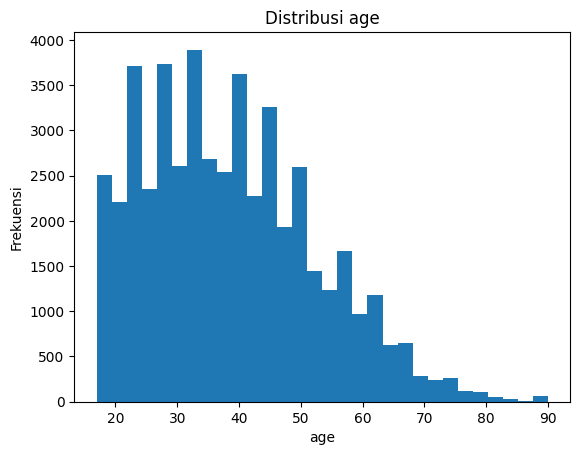

In [25]:
# Kolom age menggunakan histrogram
num_cols = ['age']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col); plt.ylabel('Frekuensi')
    plt.show()

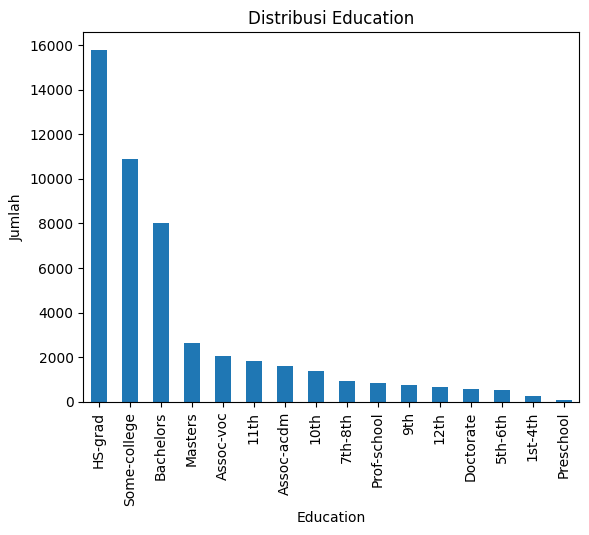

In [29]:
# Kolom edukasi menggunakan Barchart
df['education'].value_counts().plot(kind='bar')

plt.title('Distribusi Education')
plt.xlabel('Education')
plt.ylabel('Jumlah')
plt.show()

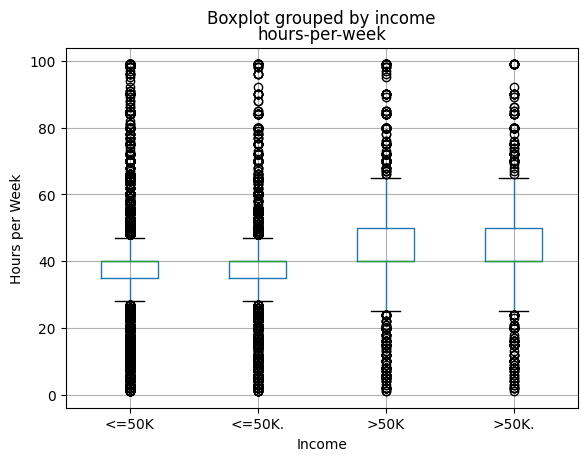

In [34]:
#  Kolom 'income' terhadap 'hours_per_week' menggunakan boxplot
df.boxplot(column='hours-per-week', by='income')

plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

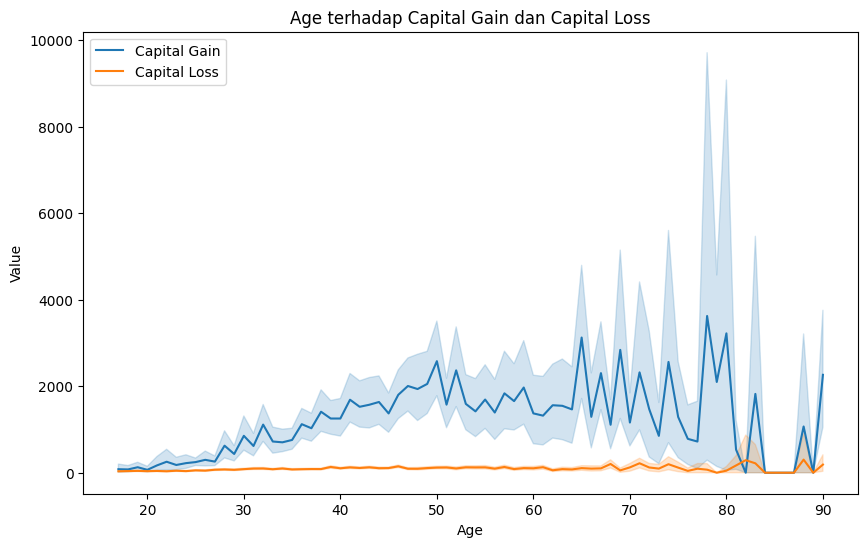

In [42]:
# kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='age', y='capital-gain', label='Capital Gain')
sns.lineplot(data=df, x='age', y='capital-loss', label='Capital Loss')

plt.title('Age terhadap Capital Gain dan Capital Loss')
plt.xlabel('Age')
plt.ylabel('Value')
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [43]:
# Jawab dengan komentar python

'''
1. Fenomena yang terjadi itu fenomena skewness positif atau miring ke kanan karena sebagian besar datanya itu berada pada rentang usia 20-50 tahun sedangkan semakin tua, jumlah datanya semakin sedikit.
2. Jika terdapat data yang hilang, strategi yang digunakan itu imputasi data dengan median, kenapa median? karena data usia tidak tersebar secara merata dan terdapat beberapa usia yang cukup tinggi, dengan adanya median hasil pengisian data yang hilang tidak terlalu dipengaruhi oleh usia yang ekstrem.
3. Terdapat banyak outlier pada kedua kategori income dan kategori <=50K memiliki outlier paling banyak.
'''

'\n1. Fenomena yang terjadi itu fenomena skewness positif atau miring ke kanan karena sebagian besar datanya itu berada pada rentang usia 20-50 tahun sedangkan semakin tua, jumlah datanya semakin sedikit.\n2. Jika terdapat data yang hilang, strategi yang digunakan itu imputasi data dengan median, kenapa median? karena data usia tidak tersebar secara merata dan terdapat beberapa usia yang cukup tinggi, dengan adanya median hasil pengisian data yang hilang tidak terlalu dipengaruhi oleh usia yang ekstrem.\n3. Terdapat banyak outlier pada kedua kategori income dan kategori <=50K memiliki outlier paling banyak.\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [47]:
from sklearn.preprocessing import LabelEncoder

# Membuat objek LabelEncoder
le = LabelEncoder()

# Encoding Sex
df['sex'] = le.fit_transform(df['sex'])
# Encoding Income
df['income'] = le.fit_transform(df['income'])

# Kemudian cek hasilnya
df[['sex', 'income']].head()

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income          0.205173       0.291074        0.198890      0.195755   

                capital-loss    income  
age                 0.056944  0.205173  
education-num       0.080972  0.291074  
hours-per-week      0.054467  0.198890  
capital-gain       -0.031441  0.195755  
capital-loss        1.000000  0.129771  
income              0.129771  1.000000  


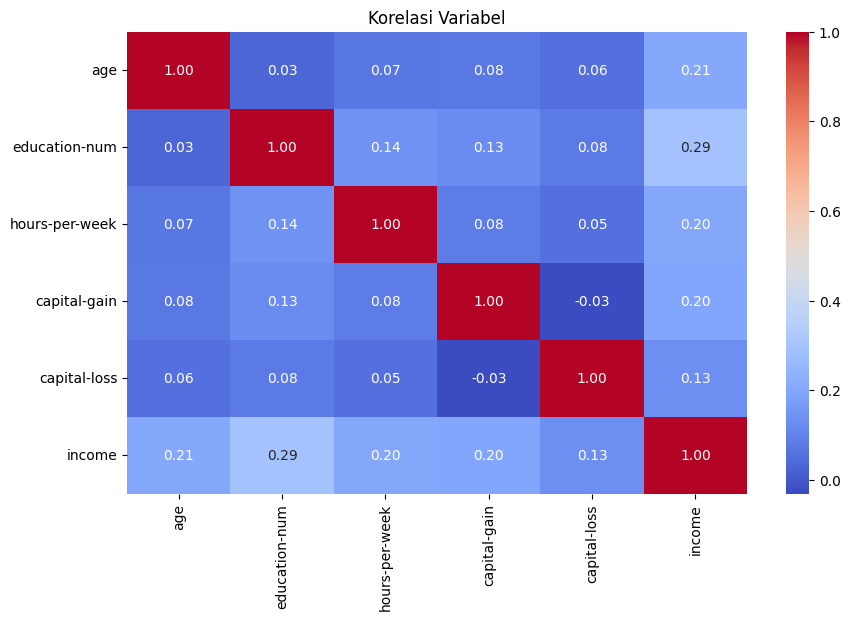

In [48]:
import seaborn as sns

# Memilih variabel yang akan dianalisis
data_korelasi = df[
    ['age', 'education-num', 'hours-per-week',
     'capital-gain', 'capital-loss', 'income']
]

# Menghitung korelasi
korelasi = data_korelasi.corr()

# Menampilkan hasil korelasi
print(korelasi)

# Membuat heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Korelasi Variabel')
plt.show()

In [ ]:
# Hasil analisis jelaskan pada cell ini
Berdasarkan hasil korelasi, variabel yang memiliki hubungan paling besar dengan income adalah eduacation-num dengan nilai 0,29. Variabel age, hours-per-Week, dan capital-gain juga memiliki hubungan positif dengan income, tetapi hubungannya masih tergolong lemah. Sementara itu, capital-loss memiliki hubungan yang paling lemah dengan income yaitu 0.13. Secara keseluruhan, tidak ada korelasi yang sangat kuat antarvariabel.

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [49]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


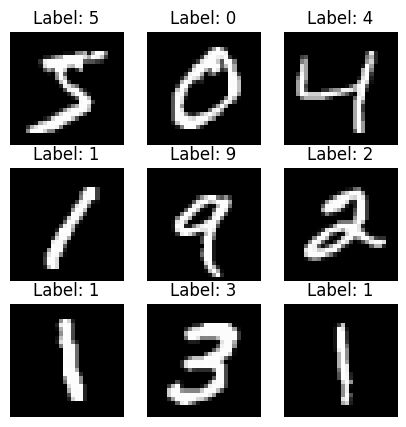

In [50]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Ukuran data sebelum upsampling: (10000, 28, 28)
Ukuran data setelah upsampling: (10000, 32, 32)


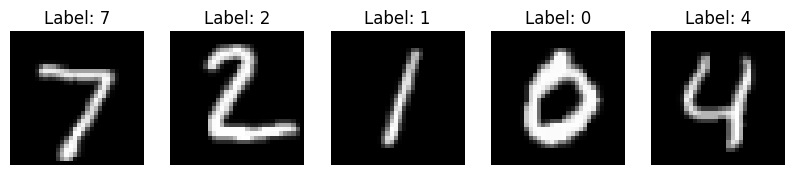

In [53]:
import cv2

# Membuat array kosong untuk menampung hasil upsampling
X_test_upsampled = np.empty((len(X_test), 32, 32), dtype=X_test.dtype)

# Proses upsampling seluruh data test
for i in range(len(X_test)):
    X_test_upsampled[i] = cv2.resize(
        X_test[i],
        (32, 32),
        interpolation=cv2.INTER_LINEAR
    )

print("Ukuran data sebelum upsampling:", X_test.shape)
print("Ukuran data setelah upsampling:", X_test_upsampled.shape)

# Menampilkan 5 data hasil upsampling
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [56]:
# Melakukan normalisasi nilai piksel menjadi 0-1
X_test_normalisasi = X_test_upsampled.astype('float32') / 255.0

# Mengecek hasilnya
print("Nilai minimum:", X_test_normalisasi.min())
print("Nilai maksimum:", X_test_normalisasi.max())

Nilai minimum: 0.0
Nilai maksimum: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [58]:
# Membuat holder array kosong
X_test_flatten = np.empty((len(X_test_normalisasi), 32 * 32), dtype='float32')

# Mengubah setiap citra 32x32 menjadi array 1 dimensi
for i in range(len(X_test_normalisasi)):
    X_test_flatten[i] = X_test_normalisasi[i].flatten()

# Melihat ukuran data
print("Ukuran data setelah flatten:", X_test_flatten.shape)

Ukuran data setelah flatten: (10000, 1024)
